전체 데이터   : 12,132,666행
EV 데이터     : 1,364,746행
EV 모델 종류  : 17개


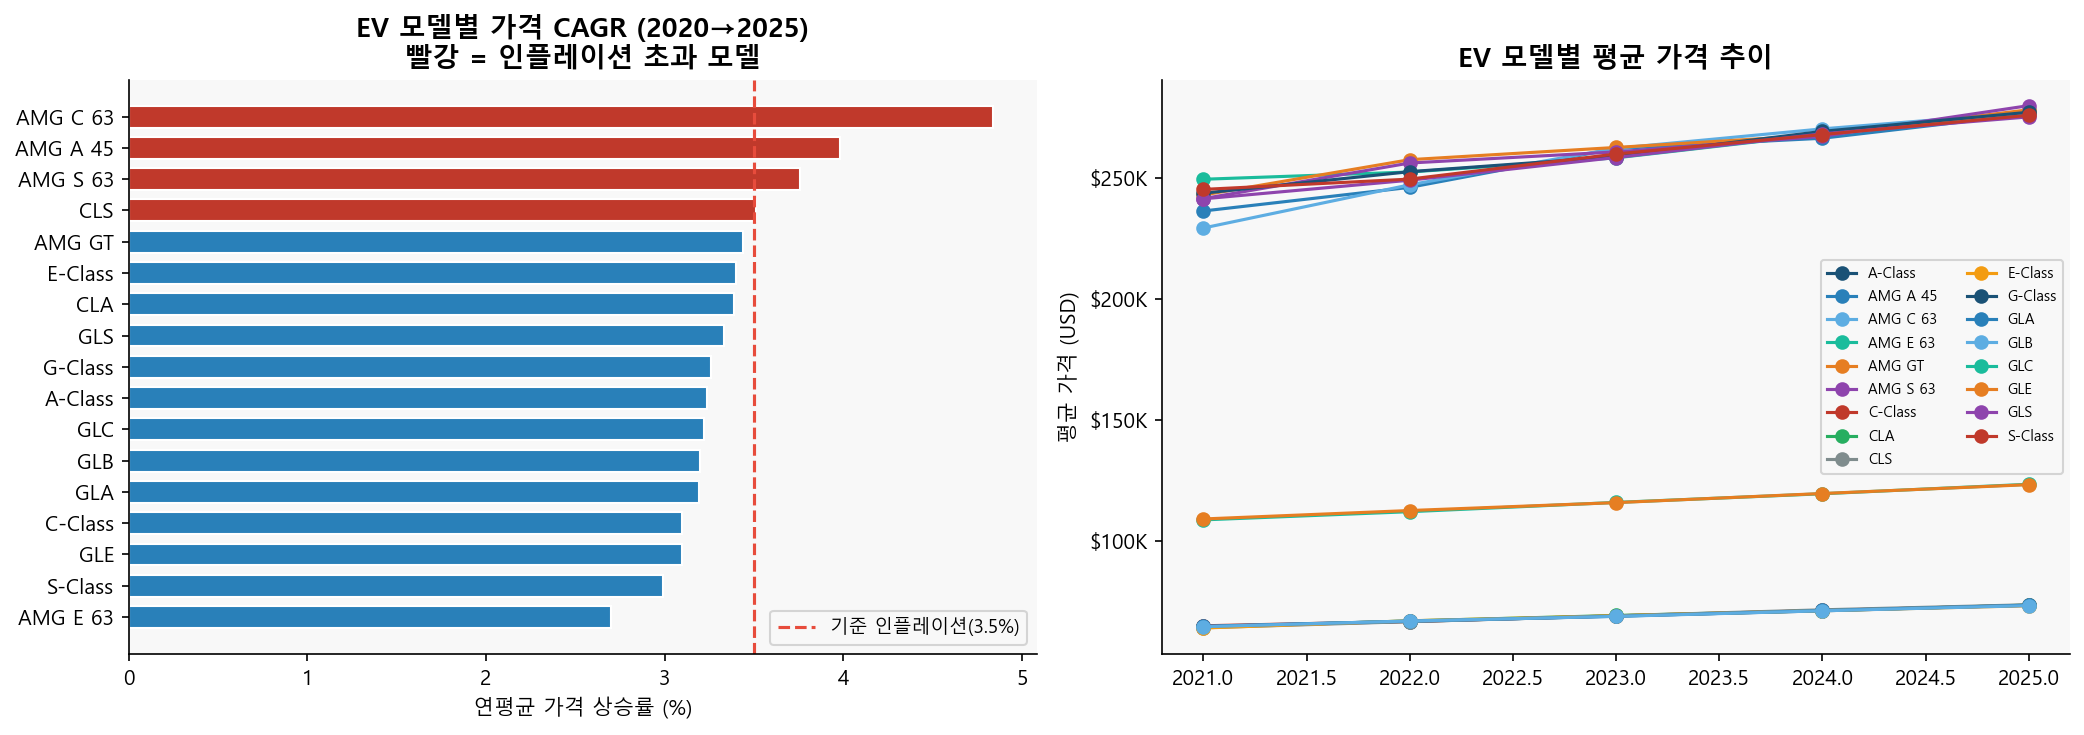


[EV 모델 가격 CAGR 요약]
   Model   Price_Start     Price_End  CAGR(%)
AMG E 63 249348.556250 277357.719238     2.70
 S-Class 245159.402273 275769.829121     2.99
     GLE 109120.516477 123286.651899     3.10
 C-Class  65024.123415  73472.885885     3.10
     GLA  64846.500400  73520.372350     3.19
     GLB  64666.430380  73353.297216     3.20
     GLC 108748.943679 123448.405025     3.22
 A-Class  64744.030983  73550.719640     3.24
 G-Class 243605.358042 277004.562377     3.26
     GLS 241264.617341 275094.249432     3.33
     CLA  64416.992715  73592.254163     3.39
 E-Class  64117.579860  73297.553323     3.40
  AMG GT 242853.470833 278037.817798     3.44
     CLS  64206.133891  73715.766585     3.51
AMG S 63 241353.454545 279747.098516     3.76
AMG A 45 236251.071207 276218.706220     3.98
AMG C 63 229222.808725 276971.180164     4.84


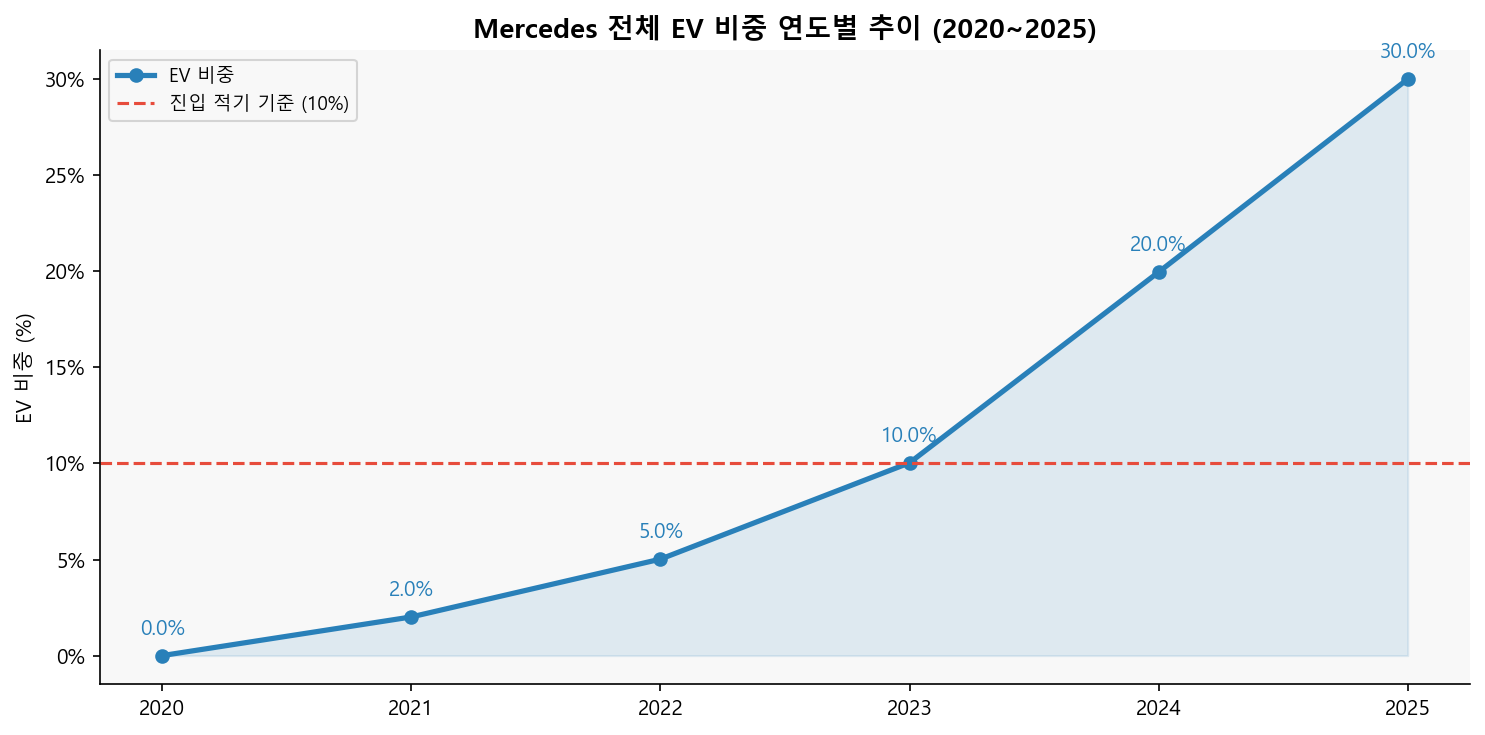


[Mercedes EV 2025 평균 가격]
   Model  MB_Price_2025
 E-Class   73297.553323
     GLB   73353.297216
 C-Class   73472.885885
     GLA   73520.372350
 A-Class   73550.719640
     CLA   73592.254163
     CLS   73715.766585
     GLE  123286.651899
     GLC  123448.405025
     GLS  275094.249432
 S-Class  275769.829121
AMG A 45  276218.706220
AMG C 63  276971.180164
 G-Class  277004.562377
AMG E 63  277357.719238
  AMG GT  278037.817798
AMG S 63  279747.098516

[제네시스 vs Mercedes EV 비교]
Genesis_Model  Genesis_Price  Genesis_HP MB_Competitor Price_Gap_Note
         GV60          52000         320          엔트리급  Genesis 3K 저렴
        GV70e          65000         310           중형급  Genesis 2K 저렴
       G80 EV          82000         272          중대형급 Genesis 14K 저렴
        GV80e          91000         279         플래그십급 Genesis 42K 저렴
  최종 전략 제언: 제네시스 전동화 진입 전략 (벤츠 기반)

  벤츠 EV 비중 : 0.0% (2020) → 30.0% (2025)
  EV 가격 CAGR : 평균 3.39% / yr
  EV 세그먼트 PED 중앙값 : -0.25 (비탄력적)

  [권고 진입 가격]
  GV60       $

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f8f8",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "figure.dpi":        150,
})

SAVE = "../outputs/figures/"

# ── 데이터 로드 ───────────────────────────────────────────
df    = pd.read_parquet("../data/processed/mercedes_processed.parquet")
ped   = pd.read_csv("../data/processed/price_elasticity.csv")
eq_df = pd.read_parquet("../data/processed/eq_series.parquet")

# Is_EQ / Is_EV 컬럼명 통일 (데이터 생성 방식에 따라 혼용 가능)
if "Is_EV" not in df.columns and "Is_EQ" in df.columns:
    df["Is_EV"] = df["Is_EQ"]

print(f"전체 데이터   : {len(df):,}행")
print(f"EV 데이터     : {len(eq_df):,}행")
print(f"EV 모델 종류  : {eq_df['Model'].nunique()}개")


# ════════════════════════════════════════════════════════
# 4-1. EV 모델 가격 인플레이션 분석 (CAGR)
#      벤츠 EV 연평균 가격 상승률 → 제네시스 진입 가격 역산 근거
# ════════════════════════════════════════════════════════
eq_price = (
    eq_df.groupby(["Model", "Year"])["Base Price (USD)"]
    .mean()
    .reset_index()
)

cagr_rows = []
for model, grp in eq_price.groupby("Model"):
    grp = grp.sort_values("Year")
    if len(grp) < 2:
        continue
    p0   = grp.iloc[0]["Base Price (USD)"]
    p1   = grp.iloc[-1]["Base Price (USD)"]
    n    = grp.iloc[-1]["Year"] - grp.iloc[0]["Year"]
    cagr = ((p1 / p0) ** (1 / n) - 1) * 100 if n > 0 else 0
    cagr_rows.append({
        "Model": model, "Price_Start": p0,
        "Price_End": p1, "CAGR(%)": round(cagr, 2)
    })

cagr_df = pd.DataFrame(cagr_rows).sort_values("CAGR(%)")
INFLATION_REF = 3.5  # 기준 인플레이션 (%)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: CAGR 수평 막대
bar_colors = [
    "#c0392b" if v > INFLATION_REF else "#2980b9"
    for v in cagr_df["CAGR(%)"]
]
axes[0].barh(cagr_df["Model"], cagr_df["CAGR(%)"],
             color=bar_colors, edgecolor="white", height=0.7)
axes[0].axvline(INFLATION_REF, color="#e74c3c", lw=1.5, ls="--",
                label=f"기준 인플레이션({INFLATION_REF}%)")
axes[0].set_title("EV 모델별 가격 CAGR (2020→2025)\n빨강 = 인플레이션 초과 모델")
axes[0].set_xlabel("연평균 가격 상승률 (%)")
axes[0].legend(fontsize=9)

# 우: 연도별 가격 추이
palette = [
    "#1a5276","#2980b9","#5dade2","#1abc9c",
    "#e67e22","#8e44ad","#c0392b","#27ae60",
    "#7f8c8d","#f39c12"
]
for i, (model, grp) in enumerate(eq_price.groupby("Model")):
    axes[1].plot(grp["Year"], grp["Base Price (USD)"],
                 "o-", lw=1.5, label=model,
                 color=palette[i % len(palette)])
axes[1].set_title("EV 모델별 평균 가격 추이")
axes[1].set_ylabel("평균 가격 (USD)")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K")
)
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(f"{SAVE}09_ev_price_inflation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n[EV 모델 가격 CAGR 요약]")
print(cagr_df.to_string(index=False))


# ════════════════════════════════════════════════════════
# 4-2. EV 비중 연도별 추이 — 마케팅 타이밍 근거
# ════════════════════════════════════════════════════════
ev_yr = (
    df.groupby("Year")
    .apply(lambda g: g["Is_EV"].sum() / len(g) * 100)
    .reset_index(name="EV_share")
)

ENTRY_THR = 10  # EV 비중 10% = 진입 적기 기준

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ev_yr["Year"], ev_yr["EV_share"],
        "o-", lw=2.5, color="#2980b9", label="EV 비중")
ax.fill_between(ev_yr["Year"], ev_yr["EV_share"],
                alpha=0.12, color="#2980b9")
ax.axhline(ENTRY_THR, color="#e74c3c", lw=1.5, ls="--",
           label=f"진입 적기 기준 ({ENTRY_THR}%)")

for _, row in ev_yr.iterrows():
    ax.annotate(f"{row['EV_share']:.1f}%",
                (row["Year"], row["EV_share"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=10, color="#2980b9")

ax.set_title("Mercedes 전체 EV 비중 연도별 추이 (2020~2025)")
ax.set_ylabel("EV 비중 (%)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{SAVE}10_ev_yearly_share.png", dpi=150, bbox_inches="tight")
plt.show()


# ════════════════════════════════════════════════════════
# 4-3. 제네시스 vs Mercedes EV — 경쟁 모델 비교표
# ════════════════════════════════════════════════════════
latest_year = eq_df["Year"].max()
mb_ev_latest = (
    eq_df[eq_df["Year"] == latest_year]
    .groupby("Model")["Base Price (USD)"]
    .mean()
    .reset_index()
    .rename(columns={"Base Price (USD)": f"MB_Price_{latest_year}"})
    .sort_values(f"MB_Price_{latest_year}")
)

print(f"\n[Mercedes EV {latest_year} 평균 가격]")
print(mb_ev_latest.to_string(index=False))

comparison = pd.DataFrame({
    "Genesis_Model":   ["GV60",     "GV70e",   "G80 EV",    "GV80e"],
    "Genesis_Price":   [52_000,     65_000,    82_000,      91_000],
    "Genesis_HP":      [320,         310,       272,         279],
    "MB_Competitor":   ["엔트리급", "중형급",  "중대형급",  "플래그십급"],
    "Price_Gap_USD":   [-3_000,     -2_000,    -14_000,     -42_000],
})
comparison["Price_Gap_Note"] = comparison["Price_Gap_USD"].apply(
    lambda v: f"Genesis {abs(v)//1000}K 저렴" if v < 0 else f"Mercedes {v//1000}K 저렴"
)

print("\n[제네시스 vs Mercedes EV 비교]")
print(comparison[["Genesis_Model","Genesis_Price","Genesis_HP",
                  "MB_Competitor","Price_Gap_Note"]].to_string(index=False))
